In [1]:
# remaking some plots to use for poster + slideshow

In [110]:
from get_cutouts import get_cutout

from astropy.table import Table
from astropy.visualization.wcsaxes import SphericalCircle
from astropy import units as u

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from astropy.coordinates import SkyCoord, match_coordinates_sky

import matplotlib.patches as patches

from tqdm import tqdm

from astropy.table import Table
from astropy import units as u
from astropy.constants import c

import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.optimize import minimize

import numpy as np

import numdifftools as ndt

from tqdm import tqdm

from curve_fit_fxns import *

In [175]:
target_galaxies = Table.read('/pscratch/sd/d/dbustos/rot_curves/shredded_mass.fits')
# target_galaxies = Table.read('/pscratch/sd/d/dbustos/rot_curves/loa_targs_v2.fits')
# target_galaxies = Table.read('/pscratch/sd/d/dbustos/rot_curves/loa_rot_velocity.fits')

target_galaxies[:5]

TARGETID,SGA_ID,TARGET_RA,TARGET_DEC,Z,Z_RR,ZWARN,DELTACHI2,DIST,DIST_R26,PA,C_TO_F_ANGLE,ANGLE_OFF_AXIS,Selection,ZERR_MOD,unique_obs,Velocity,V_err,Z_center,VI,deproj_dist,deproj_r26,manual_VI,rot_vel_filing,r_kpc,chi2_reduced,vmax_fit,rturn_fit,vmax_err,rturn_err,l10_mass
int64,int64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,int64,float64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64
169678387281926,1430874,257.7495971,56.9324928,0.028921517883227336,0.028921517883227336,0,121857.89663615823,0.003250448915035935,0.31250071154567677,6.557606220245361,206.22810010342067,199.6704938831753,1,2.4024789259983957e-05,3.0,182.8750198451699,11.489101308260244,2.401212431981059e-05,0,0.008096415535868652,0.7783957484224773,0,0,0.20122416188287864,0.38706405138543304,188.0016333989227,0.004035780336833629,145.11961827963177,4.09983872988525,14.105393802892252
1004815400304641,188925,193.6701,28.93758,0.0082724267277799,0.0082724267277799,0,20781.262633197082,0.0009923137447555642,0.026284859154548004,48.5860481262207,146.26021571620655,97.67416758998584,2,2.3542643581428787e-05,31.0,-181.63274387448345,72.81809787647651,1.6648346838273807e-05,0,0.0011151277859353821,0.02953801350383857,0,0,0.008088028889852567,5.63436883524322,170.25925589571688,0.03525810913705583,145.11961827963177,4.09983872988525,14.044273827688528
1005093910478848,1309576,234.30175,43.3014166667,0.019607169071382585,0.019607169071382585,0,21025.242969959974,0.004020441905483598,0.2179634595949638,134.6117401123047,320.7967839323471,186.18504382004244,1,2.380730399661915e-05,8.0,173.70559603525007,12.904304444072334,2.3796769180937358e-05,0,0.005374691904048404,0.2913825069989467,0,0,0.08955195966842268,1.3727806283237154,171.17940047936136,0.040082806353557265,145.11961827963177,4.09983872988525,14.099105523481835
1005093910478849,1309576,234.303916667,43.2961944444,0.0190429075748926,0.0190429075748926,0,37842.76546475291,0.0023170693385198464,0.12561714881549862,134.6117401123047,204.59833750241611,69.98659739011143,1,2.3794128780331918e-05,8.0,-126.47090634603123,37.70665102866408,2.3796769180937358e-05,0,0.0031473131687750006,0.1706278271946506,0,0,0.05243985459735577,1.3727806283237154,171.17940047936136,0.040082806353557265,145.11961827963177,4.09983872988525,14.099105523481835
1070072240013316,1274340,211.97595842881015,-1.7972709177927217,0.11250920420885363,0.11250920420885363,0,22.436569418292493,0.0017768913725439352,0.33000000681563946,111.84095001220703,111.84094537098616,0.0,1,2.5976518827107968e-05,5.0,-334.7510129281746,11.298140715623916,2.6001678649770536e-05,0,0.0017768913725439352,0.33000000681563946,0,0,0.17587919753617773,5.30287327339134,299.0027490211185,0.024965740378096176,145.11961827963177,4.09983872988525,14.822641770082772


In [4]:
SGA = Table.read('/global/cfs/projectdirs/cosmo/data/sga/2020/SGA-2020.fits', 'ELLIPSE')
SGA[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32
2,SGA-2020 2,PGC1283207,1283207,228.3770865,5.4232017,S?,152.2,0.36307806,0.724436,0.03463229,23.40448,16.976,False,LEDA-20181114,0,PGC1283207,1,True,228.3770865,5.4232017,0.36307806,2283p055,228.3770803831908,5.423191398593787,0.49470574,SB26,158.20142,0.545691,228.37700918822188,5.4232652570544015,10.897086,3.3509698,3.1147978,3.240862,5.902337,6.9126143,7.941369,8.997992,10.073601,11.199986,12.391357,13.561038,14.841172,16.966799,16.108246,15.486356,16.879545,16.024958,15.400715,16.818878,15.967034,15.341793,16.776297,15.925804,15.300776,16.746685,15.897334,15.272053,16.725166,15.876816,15.2521105,16.708357,15.862035,15.237181,16.696539,15.851936,15.226998,16.689613,15.844313,15.21976,0.013392451,0.02354,0.021872982,0.01736985,0.024445537,0.039866067,0.05026544,0.08455789,0.122911856,0.005682776,0.0054258136,0.0049038026,0.005588406,0.005323561,0.0047632363,0.00543534,0.005177031,0.0046343105,0.0053025587,0.005040888,0.0045181247,0.005206092,0.0049438984,0.0044374703,0.0051483097,0.0048758644,0.0043834248,0.0051032505,0.0048264163,0.004344248,0.0050705094,0.004792021,0.004319857,0.005054293,0.004765629,0.0043044444,16.65942,0.34037337,0.2978292,3.0239506,0.07928849,15.820566,0.2640441,0.34559453,3.3033552,0.003811298,15.195567,0.29826432,0.3001073,3.2333765,0.011723555,0
3,SGA-2020 3,PGC1310416,1310416,202.54443750000002,6.9345944,Sc,159.26,0.4017908,0.7816278,0.073888786,23.498482,16.85,False,LEDA-20181114,1,PGC1310416,1,True,202.54443750000002,6.9345944,0.4017908,

In [5]:
SGA_dict = {}
for i in range(len(SGA)):
    SGA_dict[SGA['SGA_ID'][i]] = i

In [81]:
target_galaxies = target_galaxies[target_galaxies['SGA_ID'] == 462421][np.r_[0:3,5:10,14:21]]

## Cutout

100%|██████████| 1/1 [00:02<00:00,  2.30s/it]


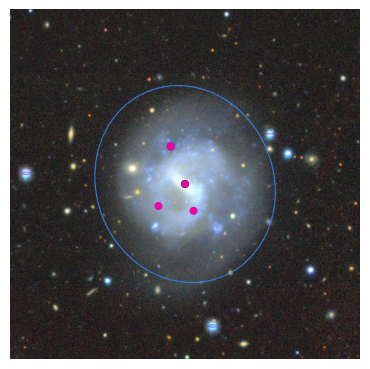

In [170]:
# for each rotation curve galaxy, grab cut out, draw fibers on image, and save image
for sga_id in tqdm(np.unique(target_galaxies['SGA_ID'])[:1]):

    sga_id = 19349 
    
    targ_list = target_galaxies[target_galaxies['SGA_ID']==sga_id]
    # if np.min(targ_list['DIST_R26']) < 0.001:
    #     center_target = targ_list[np.argmin(targ_list['DIST_R26'])]['TARGETID']
    z = targ_list[np.argmin(targ_list['DIST_R26'])]['Z']

    # else:
    #     continue
    
    ra, dec = float(SGA['RA'][SGA_dict[sga_id]]), float(SGA['DEC'][SGA_dict[sga_id]])
    
    # D26 in arcmin
    d26 = SGA['D26'][SGA_dict[sga_id]]

    dr = 10

    pix = int(2 * d26*60/0.262)

    # npix = 2000

    if (pix < 2500):
        npix = np.minimum(pix,1024)

    elif (pix > 2500):
        npix = np.minimum(pix,3000)

    img_file, wcs = get_cutout(sga_id, ra, dec, dr=dr, dir='/pscratch/sd/d/dbustos/for_poster/',size=npix)
    img = mpl.image.imread(img_file)

    fig1 = plt.figure(figsize=(7,5))

    ax = fig1.add_subplot(111, projection=wcs)
    ax.imshow(np.flip(img, axis=0))
    # ax.set(xlabel='$Right$ $Ascension$', ylabel='$Declination$')
    # ax.text(int(0.02*npix), int(0.85*npix), 'SGA_ID: {}'.format(sga_id), fontsize=9, color='yellow')
    # overlay = ax.get_coords_overlay('icrs')
    # overlay.grid(color='white', ls='dotted');

    # Add the location of the DESI fibers.
    # SDSS fibers are 2" diameter, DESI is 107 um with 70 um/" plate scale.
    r1 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                         edgecolor='black', facecolor='none', alpha=0.8, lw=3,
                         transform=ax.get_transform('icrs'))
    r2 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                         edgecolor='red', facecolor='none', alpha=0.8, lw=2,
                         transform=ax.get_transform('icrs'))
    ax.add_patch(r1)
    ax.add_patch(r2)

    for targ in targ_list:
        ra, dec = targ['TARGET_RA'], targ['TARGET_DEC']
        
        edgecolor2 = 'xkcd:hot pink'

        # Add the location of the DESI fibers.
        # SDSS fibers are 2" diameter, DESI is 107 um with 70 um/" plate scale.
        r1 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                             edgecolor='xkcd:violet', facecolor='none', alpha=.8, lw=3,
                             transform=ax.get_transform('icrs'))
        r2 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                             edgecolor=edgecolor2, facecolor='none', alpha=1, lw=2,
                             transform=ax.get_transform('icrs'))
        ax.add_patch(r1)
        ax.add_patch(r2)

    ax.set_axis_off()
        
        # ax.text(ra, dec, str(targ['TARGETID']), transform=ax.get_transform('icrs'), color='white', fontsize=6)
    
    fig1.subplots_adjust(top=0.85, right=0.85, bottom=0.15, left=0.15)
    
    fig1.savefig('/pscratch/sd/d/dbustos/for_poster/' + 'cutouts_sga_{}.png'.format(sga_id), dpi=120)
    
    # fig1.clear()
    # plt.close(fig1)

## Velocity Map

In [164]:
loa_new = target_galaxies

100%|██████████| 1/1 [00:00<00:00,  9.32it/s]


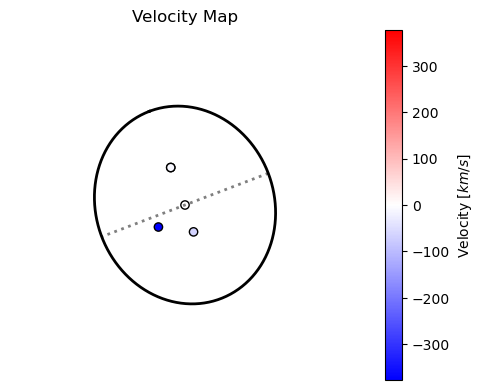

In [174]:
for sga_id in tqdm(np.unique(loa_new['SGA_ID'])[:1]):
    
    sga_id = 19349
    
    #identify all targets in the galaxy
    targ_list = loa_new[loa_new['SGA_ID']==sga_id]

    #find the index for this target in SGA
    sga_idx = SGA_dict[sga_id]
    
    #get coordinates for center of galaxy
    center_ra, center_dec = float(SGA['RA'][sga_idx]), float(SGA['DEC'][sga_idx])

    #get velocities for each point
    velocity = np.array(targ_list['Velocity'])

    #find max velocity for colormap
    v_max = max((v for v in abs(velocity) if v<=1000), default=1000)

#-------------------------------------------
# get cutout
#-------------------------------------------
    # D26 in arcmin
    d26 = SGA['D26'][sga_idx]
    
    pix = int(2 * d26*60/0.262)

    # npix = 1500
    if (pix < 2500):
        npix = np.minimum(pix,1024)

    elif (pix > 2500):
        npix = np.minimum(pix,3000)

    img_file, wcs = get_cutout(sga_id, center_ra, center_dec, dir='/pscratch/sd/d/dbustos/for_poster/',dr=10,size=npix)
    img = mpl.image.imread(img_file)

    fig1 = plt.figure(figsize=(7,5))


    ax = fig1.add_subplot(111, projection=wcs)
    
    #add the cutout to make ellipse right size, but set opacity to 0
    ax.imshow(np.flip(img, axis=0),alpha=0)
    ax.coords[0].set_format_unit(u.deg)
    # ax.set(xlabel='$Right$ $Ascension$', ylabel='$Declination$')
#---------------------------------
# generate ellipse
#---------------------------------
    
    #PA for ellipse in rad
    PA = np.radians(SGA['PA'][sga_idx])
    
    #radius semimajor axis in arcmin
    smajor = (d26/2)/60
    #radius semiminor axis in arcmin
    sminor = ((SGA['BA'][sga_idx]) * smajor)

    theta = np.linspace(0,2*np.pi,365)
    # ellipse coordinates before transformation
    smajor1 = smajor * np.cos(theta)
    sminor1 = sminor * np.sin(theta)

    # rotation matrix
    rot_ra = (smajor1*np.sin(PA) + sminor1*np.cos(PA))/np.cos(np.radians(center_dec))
    rot_dec = smajor1*np.cos(PA) - sminor1*np.sin(PA)
 
    #ellipse coordinates after transformation
    ellipse_ra = center_ra + rot_ra
    ellipse_dec = center_dec + rot_dec

    ax.plot(ellipse_ra,ellipse_dec,color = 'black',lw=2,transform= ax.get_transform('icrs'))

#----------------------------
    pa_minor = PA + np.pi/2

    minor_line = np.array([-sminor, sminor])

    # rotation matrix
    rot_line_ra = minor_line * np.sin(pa_minor) / np.cos(np.radians(center_dec))
    rot_line_dec = minor_line * np.cos(pa_minor)

    minor_line_ra = center_ra + rot_line_ra 

    minor_line_dec = center_dec + rot_line_dec 

    ax.plot(minor_line_ra, minor_line_dec,color = 'black',lw=2,ls = ':',alpha = .5,transform= ax.get_transform('icrs'))
#-------------------------------------------
# get ra and dec
#-------------------------------------------
    # velocities < 1000 km/s
    ra = np.array(targ_list['TARGET_RA'][velocity<1000]) 
    dec = np.array(targ_list['TARGET_DEC'][velocity<1000]) 

    # velocities < 1000 km/s
    ra_null = np.array(targ_list['TARGET_RA'][velocity>1000]) 
    dec_null = np.array(targ_list['TARGET_DEC'][velocity>1000]) 

#-------------------------------------------
# plot ra and dec
#-------------------------------------------

    ax1 = ax.scatter(np.array(ra), np.array(dec),
                     vmax = v_max, vmin= -v_max,
                     c = velocity[velocity < 1000], cmap = 'bwr', edgecolor = 'black',transform= ax.get_transform('icrs'))

    ax2 = ax.scatter(np.array(ra_null), np.array(dec_null),
                     vmax = v_max, vmin= -v_max,
                     c = velocity[velocity > 1000], cmap = 'bwr', marker = 'x',transform= ax.get_transform('icrs'))
    
    cbar = fig1.colorbar(ax1, ax=ax)
    # ax.set_xtick([])

    ax.set_axis_off()
    
#-------------------------
# plot indices to fibers
#-------------------------
    # loc_idx = {}
    
    # for i, j in enumerate(targ_list):
    #     ra, dec = j['TARGET_RA'], j['TARGET_DEC']

    #     if (ra, dec) not in loc_idx:
    #         loc_idx[(ra,dec)] = []

    #     loc_idx[(ra,dec)].append(str(i))

    # for i, j in loc_idx.items():
    #     combined = ', '.join(loc_idx[i])
    #     ax.text(i[0], i[1], combined, transform=ax.get_transform('icrs'), color='yellow', fontsize=7, fontweight = 'bold'
    #            ,bbox = dict(facecolor='black', alpha=0.5, edgecolor='white', lw=0.01, pad = .5))

    
    # note the galaxy still needs manual VI
    # if targ_list['manual_VI'][0] == 1:
    #     ax.annotate('needs VI again', xy = (10,10), xycoords = 'figure pixels')
    
    # ax.set_title('SGA ID: {}'.format(sga_id))
    ax.set_title('Velocity Map')
    cbar.set_label('Velocity $[km/s]$')
    fig1.subplots_adjust(top=0.85, right=0.85, bottom=0.15, left=0.15)
    
    fig1.savefig('/pscratch/sd/d/dbustos/for_poster/' + 'sga_{}_velocity_map.png'.format(sga_id), dpi=120)
    
    # fig1.clear()
    # plt.close(fig1)

## Curve Fit

In [108]:
loa_rotvel = target_galaxies

In [178]:
# find curve fit & uncertainty & plot ----------------------------------------------
for sga_id in tqdm(np.unique(loa_rotvel['SGA_ID'])[:1]):
    
    sga_id = 1130267
    
    targ_id = loa_rotvel[loa_rotvel['SGA_ID'] == sga_id]

    # grab all fibers with velocity < 1000 km/s and passed VI
    valid_fibers = targ_id[(abs(targ_id['Velocity'])<1000)]

    if len(valid_fibers) < 3:
        continue
    
    # grab radius
    r_kpc = valid_fibers['r_kpc']
    
    # make sure there are still 3 points to curve fit
    # if (len(valid_fibers) < 3) or (len(np.unique(r_kpc.round(5))) < 3):
    #     continue

    # absolute velocities
    velocity = abs(valid_fibers['Velocity'])

    v_err = valid_fibers['V_err']

    # normalize r
    idx = np.argmax(velocity)

    r26_ratio = valid_fibers['DIST_R26']
    r26 = r_kpc[idx]/r26_ratio[idx]
    
#----------------------------------------------------------------------------
#create a pseudo-center fiber if there isn't one to assist with curve fitting
#----------------------------------------------------------------------------

    # if np.all(r_kpc) != 0:
    #     z_cen_err = valid_fibers['Z_center'][0]
    #     velocity = np.append(velocity,0)
    #     r_kpc = np.append(r_kpc,0)
    #     v_err = np.append(v_err,c*z_cen_err)


#-----------------------------------------
# curve fitting
#-----------------------------------------
     
    # bounds for v max, r turn
    bounds = [(0,1000),(0.001,np.max(r_kpc))]

    # initial guess for v max, r turn
    initial_guess = [velocity[idx], r_kpc[idx]]

    #-------------
    # curve fit ----------------------------------
    #-------------
    min_fxn = minimize(fun = chi2, 
                 x0 = initial_guess, 
                 args = (velocity, v_err, r_kpc), 
                 bounds = bounds, 
                 method = 'Powell')
    #---------------------------------------------
    
    # vmax_fit, rturn_fit, alpha_fit
    min_fits = min_fxn.x
    
    #--------------------
    # get reduced chi 2 -------------------------------
    #--------------------
    chi2_fit= min_fxn.fun
    
    data_pts = len(velocity)

    prms = 2
    
    reduced_chi2 = chi2_reduced(chi2_fit, data_pts, prms)
    #------------------------------------------------
    
    

#-------------------------------
# uncertainty from curve fit
#-------------------------------
    
    hessian = ndt.Hessian(chi2)
    hess = hessian(min_fits,velocity, v_err, r_kpc)

    # get covariance matrix for errors
    # make empty matrix of nans to prevent from plotting
    try:
    #covariance matrix
        hess_inv = 2*np.linalg.inv(hess)
    # vmax_err, rturn_err, alpha_err
        fit_params_err = np.sqrt(np.diag(np.abs(hess_inv)))
    
    except np.linalg.LinAlgError:
        # Do an alternate to the above
        hess_inv = np.full((2,2),np.nan)
        
#----------------
# plot
#----------------
    fig = plt.figure()
    ax = fig.add_subplot()

    #---------------
    # curve fit -------------------------------------------
    #---------------
    r1 = np.linspace(0,r26,500)

    v_r = v_rot(r1,min_fits[0],min_fits[1])
    #------------------------------------------------------

    # sample size
    size = 1000
    
    #------------------------------
    # uncertainty on curve fit   ---------------------------------------------------------------
    #------------------------------
    if ~np.isnan(hess_inv).any():
        samples=np.random.multivariate_normal(min_fits,hess_inv,size=size, check_valid = 'ignore')

        # make sure all samples are positive
        good_samples = samples[(samples > 0).all(axis = 1)]
    
        # empty array for sample curve fit to go in
        v_sample = np.zeros((len(good_samples),500))
        
        # get curve fit for each sample distribution
        for i in range(len(good_samples)):
            indx = samples[i]
            v_x = v_rot(r1, indx[0], indx[1])
            v_sample[i] = v_x
        
        #take standard deviation for all v_rot along each r
        std_dev = np.std(v_sample[~np.isnan(v_sample).any(axis=1)], axis = 0)

        # plot uncertainty
        ax.fill_between(r1/r26, v_r - std_dev, v_r + std_dev, alpha = .12, color = 'xkcd:steel blue')
        
        # plot curve fit
        ax.plot(r1/r26, v_r, color = 'dodgerblue', zorder =1 )
        
    else:
        # plot curve fit
        ax.plot(r1/r26, v_r, color = 'mediumseagreen', zorder = 1)
        
        # note the covariance matrix returned NAN
        ax.annotate('invalid hessian', xy = (10,10), xycoords = 'figure pixels')
    #------------------------------------------------------------------------------------------------

    
    

    #------------------------------
    # v vs r points and errorbars -------------------------------------------------------------------------------------
    #------------------------------
    ax.errorbar(r_kpc/r26, velocity, yerr = v_err, ls = 'none', ecolor = 'xkcd:hot pink', capsize = 5, zorder=2, alpha = .6)
    ax.scatter(r_kpc/r26, velocity, c = 'xkcd:hot pink', zorder = 3)
    # ------------------------------------------------------------------------------------------------------------------
    
    ax.grid(ls=':')
    ax.set_title('Rotation Curve')
    ax.set_xlim(None, 1.01)
    ax.set_ylim(-1, None)
    ax.set(xlabel='$r/R_{26}$', ylabel='$v_{rot}$ $($ $km/s$ $)$')

    
    
#-----------------------------------------  
# save everything to table or $PSCRATCH
#----------------------------------------- 
    
    fig.savefig('/pscratch/sd/d/dbustos/for_poster/' + 'sga_{}_curve_fit.png'.format(sga_id), dpi=120)
    
    # fig.clear()
    # plt.close(fig)
    
    # np.save('/pscratch/sd/d/dbustos/hessian/' + str(sga_id) + '_hessian.npy', hess)
    
    # table_idx = (loa_rotvel['SGA_ID'] == sga_id) & (abs(loa_rotvel['Velocity']) < 1000)
    # loa_rotvel['chi2_reduced'][table_idx] = reduced_chi2

    # loa_rotvel['vmax_fit'][table_idx] = min_fits[0]
    # loa_rotvel['rturn_fit'][table_idx] = min_fits[1]

    # loa_rotvel['vmax_err'] = fit_params_err[0]
    # loa_rotvel['rturn_err'] = fit_params_err[1]
    

    # sanity check ---------------------------------
    # print('sga_id:',str(sga_id))
    # print('minimize fits (v, r): ', min_fits)
    # print('fit_params_err (v, r): ', fit_params_err)
    # print('reduced chi2: ', reduced_chi2)

# save new table
# loa_rotvel.write('/pscratch/sd/d/dbustos/rot_curves/loa_rotvel_curvefit.fits',format='fits',overwrite=True)

100%|██████████| 1/1 [00:00<00:00, 535.81it/s]
